DPPU EMERGENCE ENGINE
Dylan Michael Scott — Horizon Tech

Step 1: Dual competing fields (Activator vs Inhibitor)
Step 2: Multiple information seeds — field selects survivors
Step 3: Attractor feedback — memory influences perception

This is the emergence loop.

Step 0 — Seeds planted. Field initializing...
  t=   0 | Δ:0.099 | π:3.2177 | φ:1.5632 | Entropy_A:10.16 | High-Δ:3.6% | Contrast:0.0681
  t=  50 | Δ:0.574 | π:3.4979 | φ:1.3615 | Entropy_A:9.00 | High-Δ:38.2% | Contrast:0.0996
  t= 100 | Δ:0.589 | π:3.5033 | φ:1.3576 | Entropy_A:8.65 | High-Δ:41.0% | Contrast:0.0757
  t= 150 | Δ:0.578 | π:3.4980 | φ:1.3614 | Entropy_A:8.34 | High-Δ:38.4% | Contrast:0.0685
  t= 200 | Δ:0.590 | π:3.5040 | φ:1.3571 | Entropy_A:8.17 | High-Δ:40.5% | Contrast:0.0555
  t= 250 | Δ:0.569 | π:3.4932 | φ:1.3649 | Entropy_A:8.16 | High-Δ:41.0% | Contrast:0.0573
  t= 300 | Δ:0.593 | π:3.5051 | φ:1.3563 | Entropy_A:8.08 | High-Δ:43.8% | Contrast:0.0523
  t= 350 | Δ:0.572 | π:3.4943 | φ:1.3641 | Entropy_A:8.

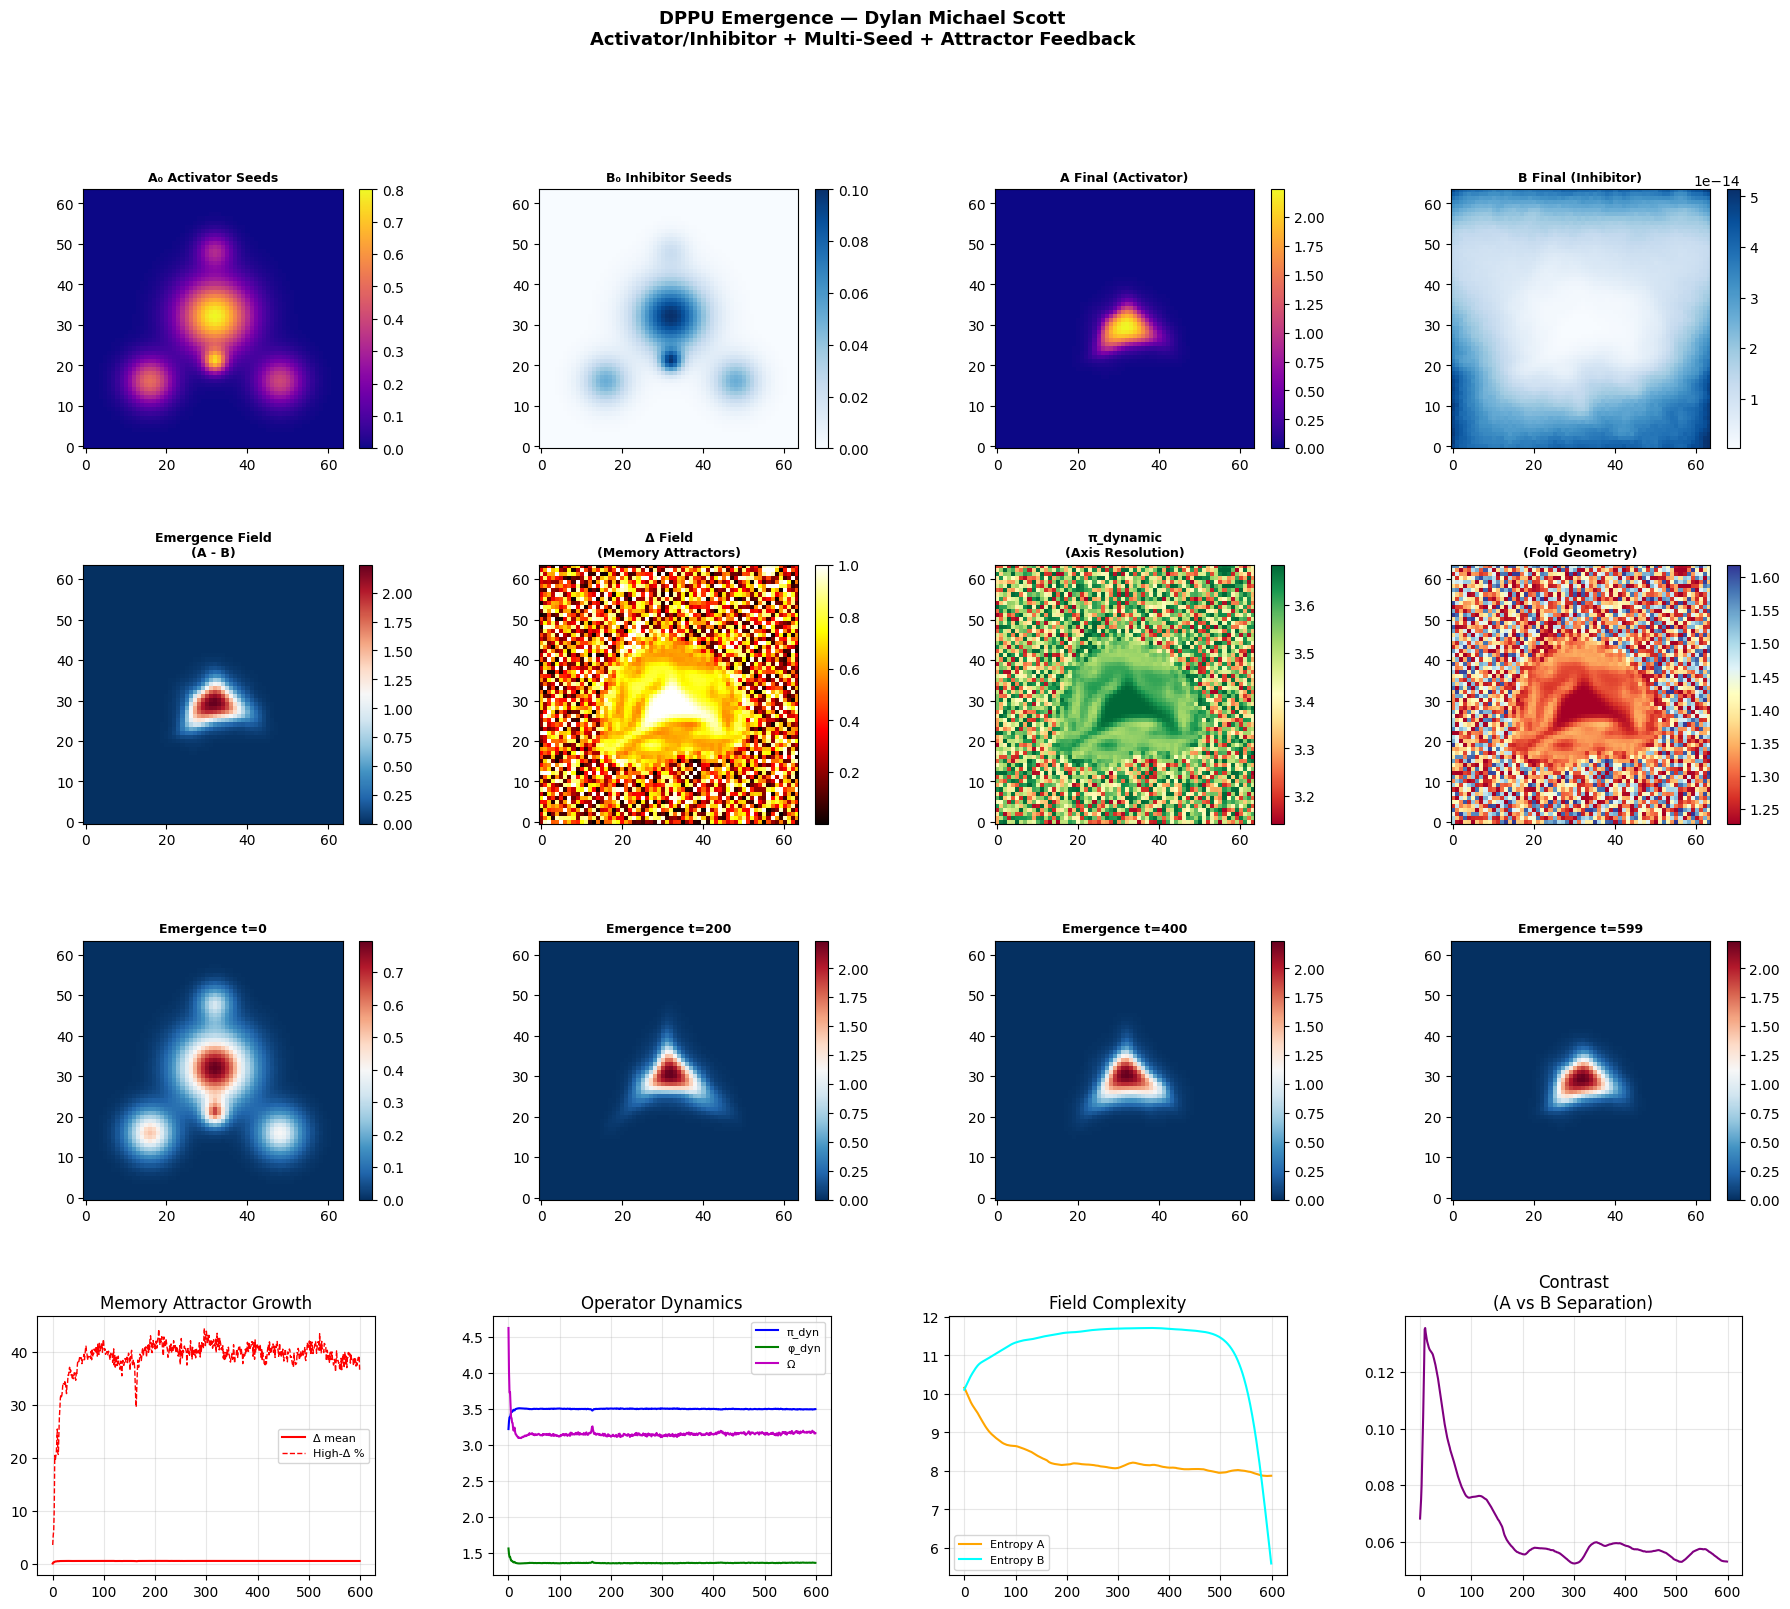


FINAL STATE
Δ mean:          0.5723
π_dynamic:       3.49424
φ_dynamic:       1.36414
Ω:               3.16123
Entropy A:       7.875 bits
Entropy B:       5.598 bits
High-Δ regions:  36.6%
Contrast (A-B):  0.05292

Field stable: True
A max: 2.2400 | B max: 0.0000

The field selected its own memory structure.
Attractor zones cover 36.6% of field
The rest is processing space.

This is emergence.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

PI_CLASSICAL = np.pi
PHI_CLASSICAL = (1 + 5**0.5) / 2
EPS = 1e-10

# ============================================================
# CORE OPERATORS (same as before)
# ============================================================

def delta(D, t=0):
    magnitude = np.abs(D)
    gy, gx = np.gradient(D)
    grad_mag = np.sqrt(gx**2 + gy**2 + EPS)
    collapse_rate = magnitude / (grad_mag + EPS)
    return np.tanh(collapse_rate / (np.mean(collapse_rate) + EPS))

def pi_dynamic(D, delta_field=None):
    if delta_field is None:
        delta_field = delta(D)
    return 4.0 - (4.0 - PI_CLASSICAL) * np.exp(-delta_field)

def phi_dynamic(D, delta_field=None):
    if delta_field is None:
        delta_field = delta(D)
    return PHI_CLASSICAL * np.exp(-delta_field) + (1.0 - np.exp(-delta_field))

def omega(D, delta_field=None):
    if delta_field is None:
        delta_field = delta(D)
    return (pi_dynamic(D, delta_field) * phi_dynamic(D, delta_field)) / (1.0 + delta_field)

def laplacian_2d(D):
    return (np.roll(D,1,0) + np.roll(D,-1,0) + np.roll(D,1,1) + np.roll(D,-1,1) - 4.0*D)

def gradient_2d(D):
    gx = (np.roll(D,-1,1) - np.roll(D,1,1)) * 0.5
    gy = (np.roll(D,-1,0) - np.roll(D,1,0)) * 0.5
    return gx, gy

def phi_weighted_divergence(D, phi_field):
    gx, gy = gradient_2d(D)
    flux_x = phi_field * gx
    flux_y = phi_field * gy
    div_x = (np.roll(flux_x,-1,1) - np.roll(flux_x,1,1)) * 0.5
    div_y = (np.roll(flux_y,-1,0) - np.roll(flux_y,1,0)) * 0.5
    return div_x + div_y

def pi_axis_modulation(D, pi_field):
    return laplacian_2d(D) * (pi_field / PI_CLASSICAL)

def shannon_entropy(D):
    flat = np.abs(D.ravel())
    flat = flat / (flat.sum() + EPS)
    flat = flat[flat > EPS]
    return -np.sum(flat * np.log2(flat + EPS))

# ============================================================
# STEP 1 — TWO COMPETING FIELDS (Activator / Inhibitor)
# ============================================================

def dppu_step_dual(A, B, t, lr=0.05, rng=None):
    """
    A = Activator field (wants to fold inward, build structure)
    B = Inhibitor field (wants to spread outward, dissolve structure)

    The tension between them is where emergence lives.
    """
    if rng is None:
        rng = np.random.RandomState(42)

    # Compute delta from COMBINED field state
    # The inhibitor modulates the activator's collapse rate
    combined = A - 0.5 * B
    delta_A = delta(combined)
    delta_B = delta(B)

    pi_A = pi_dynamic(A, delta_A)
    phi_A = phi_dynamic(A, delta_A)
    omega_A = omega(A, delta_A)

    pi_B = pi_dynamic(B, delta_B)
    phi_B = phi_dynamic(B, delta_B)

    # Activator dynamics
    # Wants to fold inward, amplify where it already exists
    # Inhibited by B — where B is high, A growth is suppressed
    dA = (0.7 * pi_axis_modulation(A, pi_A) +
          0.5 * phi_weighted_divergence(A, phi_A) +
          0.05 * A * (1.0 - A**2) -          # self amplification with saturation
          0.3 * A * B)                         # inhibitor suppression

    # Inhibitor dynamics
    # Spreads faster than activator, dissolves structure
    # Activated by A — where A is high, B grows
    dB = (1.2 * pi_axis_modulation(B, pi_B) +    # faster diffusion
          0.8 * phi_weighted_divergence(B, phi_B) +
          0.1 * A * B -                           # activated by A
          0.4 * B)                                # natural decay

    # Entropy modulation
    entropy_A = shannon_entropy(A)
    entropy_scale = 1.0 + 0.2 * np.tanh(entropy_A / 8.0)
    dA *= entropy_scale

    # Omega bounds
    mean_omega = float(np.mean(omega_A))
    dA *= np.tanh(mean_omega)

    # Small noise keeps field alive
    noise_scale = 0.01
    dA += noise_scale * rng.normal(size=A.shape) * np.std(A)
    dB += noise_scale * rng.normal(size=B.shape) * np.std(B + EPS)

    A_new = (A + lr * dA) * (1.0 - 0.003)
    B_new = (B + lr * dB) * (1.0 - 0.005)

    # Soft normalization
    for field, name in [(A_new, 'A'), (B_new, 'B')]:
        mx = np.max(np.abs(field))
        if mx > 2.0:
            field /= mx / 2.0

    return A_new, B_new, {
        'delta_mean': float(np.mean(delta_A)),
        'pi_mean': float(np.mean(pi_A)),
        'phi_mean': float(np.mean(phi_A)),
        'omega_mean': mean_omega,
        'entropy_A': entropy_A,
        'entropy_B': float(shannon_entropy(B)),
        'A_max': float(np.max(np.abs(A_new))),
        'B_max': float(np.max(np.abs(B_new))),
    }

# ============================================================
# STEP 2 — INFORMATION INJECTION
# Multiple seeds with different shapes, values, locations
# The field decides which ones survive
# ============================================================

def multi_seed(shape, rng=None):
    """
    Drop multiple information points into the field.
    Different amplitudes, locations, sizes.
    The field will select which ones persist.
    """
    if rng is None:
        rng = np.random.RandomState(42)

    H, W = shape
    A = np.zeros(shape)
    B = np.zeros(shape)

    # Seed definitions — (cy, cx, sigma, amplitude_A, amplitude_B)
    seeds = [
        (H//2,   W//2,   6.0, 0.8,  0.1),   # strong center seed
        (H//4,   W//4,   4.0, 0.5,  0.05),  # top-left weak seed
        (H//4,   3*W//4, 4.0, 0.4,  0.05),  # top-right weak seed
        (3*H//4, W//2,   3.0, 0.3,  0.02),  # bottom mid weak seed
        (H//3,   W//2,   2.0, 0.6,  0.08),  # slightly off-center strong
    ]

    y, x = np.indices(shape)
    for cy, cx, sigma, amp_A, amp_B in seeds:
        r2 = (y - cy)**2 + (x - cx)**2
        A += amp_A * np.exp(-r2 / (2 * sigma**2))
        B += amp_B * np.exp(-r2 / (2 * sigma**2))

    # Clip to valid range
    A = np.clip(A, 0, 1)
    B = np.clip(B, 0, 0.5)

    return A, B

# ============================================================
# STEP 3 — ATTRACTOR FEEDBACK
# High-delta regions influence surrounding processing space
# Past structure shapes future evolution
# This is the memory->perception loop
# ============================================================

def attractor_feedback(A, B, delta_field, feedback_strength=0.15):
    """
    The high-Δ attractor zones feed back into the field.

    Where delta is high (folded, stable memory):
    - Amplify the activator slightly
    - Suppress the inhibitor slightly

    This means: what the field has already learned
    biases what it pays attention to next.

    That's the loop. Memory influencing perception.
    """
    # Attractor mask — where is the field folded?
    attractor_mask = np.where(delta_field > 0.7, delta_field, 0.0)

    # Smooth the mask so feedback isn't sharp
    # Simple box blur
    smooth_mask = (
        attractor_mask +
        np.roll(attractor_mask, 1, 0) + np.roll(attractor_mask, -1, 0) +
        np.roll(attractor_mask, 1, 1) + np.roll(attractor_mask, -1, 1)
    ) / 5.0

    # Feedback: attractor zones boost activator, suppress inhibitor
    A_feedback = A + feedback_strength * smooth_mask * A
    B_feedback = B - feedback_strength * 0.5 * smooth_mask * B

    return A_feedback, B_feedback

# ============================================================
# EVOLUTION ENGINE — ALL 3 STEPS COMBINED
# ============================================================

def evolve_emergence(shape=(64,64), steps=600, lr=0.05,
                     record_every=50, rng=None):
    if rng is None:
        rng = np.random.RandomState(42)

    # Initialize with multiple seeds
    A, B = multi_seed(shape, rng)
    A0, B0 = A.copy(), B.copy()

    history = []
    snapshots = []

    print("Step 0 — Seeds planted. Field initializing...")

    for t in range(steps):
        # Core dual field step
        A, B, metrics = dppu_step_dual(A, B, t, lr=lr, rng=rng)

        # Attractor feedback — memory influences perception
        delta_field = delta(A - 0.5*B)
        A, B = attractor_feedback(A, B, delta_field, feedback_strength=0.12)

        # Track emergence — are distinct structures forming?
        delta_A = delta(A)
        high_delta = np.sum(delta_A > 0.7) / delta_A.size
        metrics['high_delta_pct'] = float(high_delta)
        metrics['t'] = t

        # Contrast — are activator and inhibitor separating?
        contrast = float(np.mean(np.abs(A - B)))
        metrics['contrast'] = contrast

        history.append(metrics)

        if t % record_every == 0 or t == steps-1:
            snapshots.append((t, A.copy(), B.copy()))
            print(f"  t={t:4d} | Δ:{metrics['delta_mean']:.3f} | "
                  f"π:{metrics['pi_mean']:.4f} | φ:{metrics['phi_mean']:.4f} | "
                  f"Entropy_A:{metrics['entropy_A']:.2f} | "
                  f"High-Δ:{high_delta*100:.1f}% | Contrast:{contrast:.4f}")

    return A0, B0, A, B, history, snapshots

# ============================================================
# VISUALIZATION
# ============================================================

def visualize_emergence(A0, B0, A_final, B_final, history, snapshots):
    fig = plt.figure(figsize=(22, 18))
    gs = GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.35)

    delta_final = delta(A_final - 0.5*B_final)
    omega_final = omega(A_final, delta_final)
    pi_final = pi_dynamic(A_final, delta_final)
    phi_final = phi_dynamic(A_final, delta_final)

    # Emergence field — where A dominates B
    emergence = A_final - B_final

    def show(ax, data, title, cmap='viridis'):
        im = ax.imshow(data, cmap=cmap, origin='lower')
        ax.set_title(title, fontsize=9, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046)

    # Row 1: Seeds and final state
    show(fig.add_subplot(gs[0,0]), A0, 'A₀ Activator Seeds', 'plasma')
    show(fig.add_subplot(gs[0,1]), B0, 'B₀ Inhibitor Seeds', 'Blues')
    show(fig.add_subplot(gs[0,2]), A_final, 'A Final (Activator)', 'plasma')
    show(fig.add_subplot(gs[0,3]), B_final, 'B Final (Inhibitor)', 'Blues')

    # Row 2: Emergence and operators
    show(fig.add_subplot(gs[1,0]), emergence, 'Emergence Field\n(A - B)', 'RdBu_r')
    show(fig.add_subplot(gs[1,1]), delta_final, 'Δ Field\n(Memory Attractors)', 'hot')
    show(fig.add_subplot(gs[1,2]), pi_final, 'π_dynamic\n(Axis Resolution)', 'RdYlGn')
    show(fig.add_subplot(gs[1,3]), phi_final, 'φ_dynamic\n(Fold Geometry)', 'RdYlBu')

    # Row 3: Evolution snapshots
    n_snaps = min(4, len(snapshots))
    for i in range(n_snaps):
        t, A_s, B_s = snapshots[i * (len(snapshots)-1) // max(n_snaps-1, 1)]
        show(fig.add_subplot(gs[2,i]), A_s - B_s,
             f'Emergence t={t}', 'RdBu_r')

    # Row 4: Metrics
    times = [h['t'] for h in history]

    ax1 = fig.add_subplot(gs[3,0])
    ax1.plot(times, [h['delta_mean'] for h in history], 'r-', lw=1.5, label='Δ mean')
    ax1.plot(times, [h['high_delta_pct']*100 for h in history], 'r--', lw=1, label='High-Δ %')
    ax1.set_title('Memory Attractor Growth')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[3,1])
    ax2.plot(times, [h['pi_mean'] for h in history], 'b-', lw=1.5, label='π_dyn')
    ax2.plot(times, [h['phi_mean'] for h in history], 'g-', lw=1.5, label='φ_dyn')
    ax2.plot(times, [h['omega_mean'] for h in history], 'm-', lw=1.5, label='Ω')
    ax2.set_title('Operator Dynamics')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[3,2])
    ax3.plot(times, [h['entropy_A'] for h in history], 'orange', lw=1.5, label='Entropy A')
    ax3.plot(times, [h['entropy_B'] for h in history], 'cyan', lw=1.5, label='Entropy B')
    ax3.set_title('Field Complexity')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[3,3])
    ax4.plot(times, [h['contrast'] for h in history], 'purple', lw=1.5)
    ax4.set_title('Contrast\n(A vs B Separation)')
    ax4.grid(True, alpha=0.3)

    plt.suptitle('DPPU Emergence — Dylan Michael Scott\nActivator/Inhibitor + Multi-Seed + Attractor Feedback',
                 fontsize=13, fontweight='bold')
    plt.show()

# ============================================================
# RUN
# ============================================================

rng = np.random.RandomState(42)
print("="*60)
print("DPPU EMERGENCE ENGINE")
print("Dylan Michael Scott — Horizon Tech")
print("="*60)
print("\nStep 1: Dual competing fields (Activator vs Inhibitor)")
print("Step 2: Multiple information seeds — field selects survivors")
print("Step 3: Attractor feedback — memory influences perception")
print("\nThis is the emergence loop.\n")

A0, B0, A_final, B_final, history, snapshots = evolve_emergence(
    shape=(64, 64),
    steps=600,
    lr=0.05,
    record_every=50,
    rng=rng
)

print("\nGenerating visualization...")
visualize_emergence(A0, B0, A_final, B_final, history, snapshots)

final = history[-1]
print(f"\nFINAL STATE")
print(f"Δ mean:          {final['delta_mean']:.4f}")
print(f"π_dynamic:       {final['pi_mean']:.5f}")
print(f"φ_dynamic:       {final['phi_mean']:.5f}")
print(f"Ω:               {final['omega_mean']:.5f}")
print(f"Entropy A:       {final['entropy_A']:.3f} bits")
print(f"Entropy B:       {final['entropy_B']:.3f} bits")
print(f"High-Δ regions:  {final['high_delta_pct']*100:.1f}%")
print(f"Contrast (A-B):  {final['contrast']:.5f}")
print(f"\nField stable: {not np.any(np.isnan(A_final)) and not np.any(np.isnan(B_final))}")
print(f"A max: {np.max(np.abs(A_final)):.4f} | B max: {np.max(np.abs(B_final)):.4f}")

# What survived?
delta_final = delta(A_final - 0.5*B_final)
attractor_mask = delta_final > 0.7
n_attractors = len(np.unique(attractor_mask.astype(int)))
print(f"\nThe field selected its own memory structure.")
print(f"Attractor zones cover {np.sum(attractor_mask)/attractor_mask.size*100:.1f}% of field")
print(f"The rest is processing space.")
print(f"\nThis is emergence.")

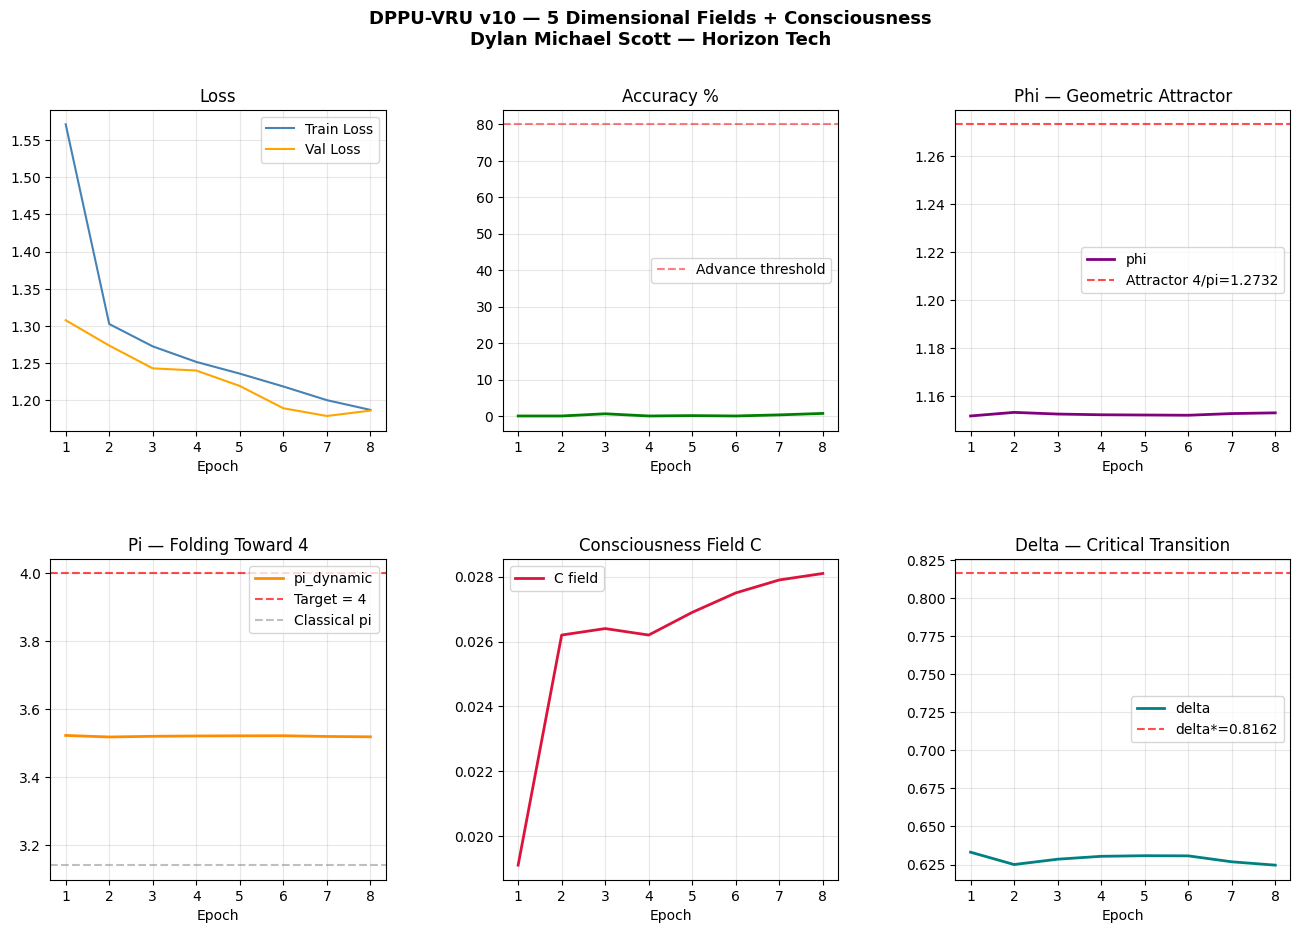

Done. Add new rows to the rows[] list as epochs come in.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Paste your real CSV rows here as they come in ──────────────────
# Format: epoch, level, train_loss, val_loss, acc, phi, pi, delta, C, lr
rows = [
    [1, 1, 1.5714, 1.3076, 0.0, 1.1517, 3.5233, 0.6331, 0.0191, 1e-3],
    [2, 1, 1.3025, 1.2735, 0.0, 1.1532, 3.5188, 0.6250, 0.0262, 1e-3],
    [3, 1, 1.2724, 1.2428, 0.6, 1.1525, 3.5208, 0.6285, 0.0264, 1e-3],
    [4, 1, 1.2515, 1.2399, 0.0, 1.1522, 3.5218, 0.6304, 0.0262, 1e-3],
    [5, 1, 1.2357, 1.2191, 0.1, 1.1521, 3.5222, 0.6308, 0.0269, 1e-3],
    [6, 1, 1.2184, 1.1891, 0.0, 1.1520, 3.5224, 0.6307, 0.0275, 1e-3],
    [7, 1, 1.2000, 1.1787, 0.3, 1.1527, 3.5203, 0.6268, 0.0279, 1e-3],
    [8, 1, 1.1869, 1.1859, 0.7, 1.1530, 3.5193, 0.6246, 0.0281, 1e-3],
]

cols = ['epoch','level','train_loss','val_loss','acc','phi','pi','delta','C','lr']
df   = pd.DataFrame(rows, columns=cols)

# ── Constants ──────────────────────────────────────────────────────
PHI_TARGET   = 4 / np.pi       # 1.2732
PI_TARGET    = 4.0
DELTA_TARGET = 0.8162

# ── Plot ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('DPPU-VRU v10 — 5 Dimensional Fields + Consciousness\nDylan Michael Scott — Horizon Tech',
             fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df.epoch, df.train_loss, label='Train Loss', color='steelblue')
ax1.plot(df.epoch, df.val_loss,   label='Val Loss',   color='orange')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

# 2. Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df.epoch, df.acc, color='green', linewidth=2)
ax2.axhline(80, color='red', linestyle='--', alpha=0.5, label='Advance threshold')
ax2.set_title('Accuracy %'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

# 3. Phi tracking toward attractor
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(df.epoch, df.phi, color='purple', linewidth=2, label='phi')
ax3.axhline(PHI_TARGET, color='red', linestyle='--', alpha=0.7, label=f'Attractor 4/pi={PHI_TARGET:.4f}')
ax3.set_title('Phi — Geometric Attractor'); ax3.set_xlabel('Epoch'); ax3.legend(); ax3.grid(True, alpha=0.3)

# 4. Pi folding toward 4
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(df.epoch, df.pi, color='darkorange', linewidth=2, label='pi_dynamic')
ax4.axhline(PI_TARGET,  color='red',   linestyle='--', alpha=0.7, label='Target = 4')
ax4.axhline(np.pi,      color='gray',  linestyle='--', alpha=0.5, label='Classical pi')
ax4.set_title('Pi — Folding Toward 4'); ax4.set_xlabel('Epoch'); ax4.legend(); ax4.grid(True, alpha=0.3)

# 5. Consciousness field growing
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(df.epoch, df.C, color='crimson', linewidth=2, label='C field')
ax5.set_title('Consciousness Field C'); ax5.set_xlabel('Epoch'); ax5.legend(); ax5.grid(True, alpha=0.3)

# 6. Delta tracking toward delta*
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(df.epoch, df.delta, color='teal', linewidth=2, label='delta')
ax6.axhline(DELTA_TARGET, color='red', linestyle='--', alpha=0.7, label=f'delta*={DELTA_TARGET}')
ax6.set_title('Delta — Critical Transition'); ax6.set_xlabel('Epoch'); ax6.legend(); ax6.grid(True, alpha=0.3)

plt.savefig('dppu_v10_training.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done. Add new rows to the rows[] list as epochs come in.')